In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Library to help with statistical analysis
import scipy.stats as stats
from mpl_toolkits.mplot3d import axes3d
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap
# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from imblearn.pipeline import Pipeline as ImbPipeline

import statsmodels.api as sm
# To build model for prediction
from sklearn.linear_model import LogisticRegression
# Import standard scalar
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
# Import model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

# Over and under sampling lib
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
# validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.base import BaseEstimator
from sklearn.preprocessing import FunctionTransformer

from typing import Any, List
# import RFE
from sklearn.feature_selection import RFE
from sklearn import metrics
# Model hyper tuning lib
from sklearn.model_selection import RandomizedSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")
# Preventing scientific notation.
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [2]:
#  store pellete for future use
pellete='Set2'
colors = sns.color_palette(pellete)  # Get Set2 color palette for future use
sns.set(style="darkgrid") # Set grid style

In [3]:
path="/content/drive/MyDrive/notebook-data/cirrhosis 2.csv"

In [4]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive')
     

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
##### Utility #####
def plot_bar_chart_percentage(df, column_name, xlabel, pellete, bar_width=0.6):
    """
    Plots the percentage distribution of a specified categorical column in a DataFrame.

    Parameters:
    - df: DataFrame containing the data.
    - column_name: The name of the column to analyze.
    - colors: List of colors for the bar plot.
    - figsize: Tuple specifying the figure size.
    - bar_width: Width of the bars in the bar plot.
    """
    # Calculate the percentage of each category in the specified column
    percentages = df[column_name].value_counts(normalize=True)*100
    percentages = percentages.reset_index().rename(columns={ column_name: column_name, 'proportion': 'percent'})
    n=df[column_name].nunique()
    # Increase figure size for better readability
    plt.figure(figsize=(n+1,6))

    # Plot the bar plot with reduced bar width
    ax=sns.barplot(x=column_name, y='percent', data=percentages, palette=pellete,hue=column_name, width=bar_width)

    # Annotate the plot with the count values
    annotate_chart(plt, ax)

    # Set labels and title
    plt.ylabel('Percentage')
    plt.xlabel(xlabel)
    plt.title(f'Overview of {xlabel}')
    plt.xticks(rotation=45)

    # Show the plot
    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.legend([],[], frameon=False)
    plt.show()

     

def plot_pie_chart_with_legend(df, column, title=None, colors=None):
    """
    Creates a pie chart with a legend showing the share of each category in a column.

    Parameters:
    - df (DataFrame): The DataFrame containing the data.
    - column (str): The column name for which the pie chart will be created.
    - title (str, optional): Title of the pie chart. Default is "Market Segment Proportions".
    - colors (list, optional): List of colors for the pie chart wedges. If not provided, default pastel colors will be used.

    Returns:
    - plt (matplotlib.pyplot): The matplotlib plot object.
    """
    # Calculate proportions
    proportions = df[column].value_counts(normalize=True)

    # Create the pie chart without annotations
    plt.pie(proportions, labels=None, colors=colors, wedgeprops={'edgecolor': 'white'})

    # Generate legend labels with percentages
    legend_labels = [f'{label}: {percent:.1%}' for label, percent in zip(proportions.index, proportions)]

    # Add the legend
    plt.legend(legend_labels, loc='best', title=column.replace('_', ' ').title())

    # Add title and adjust layout
    plt.title(title)
    plt.tight_layout()

    # Return the plot
    return plt
     

def plot_histogram_and_boxplot(df, column, xlabel, ylabel, title):
    """
    Plots a histogram with KDE and a box plot for a specified column in a DataFrame.

    Parameters:
    df (DataFrame): The DataFrame containing the data.
    column (str): The column name for which the plots are to be drawn.
    xlabel (str): The label for the x-axis.
    ylabel (str): The label for the y-axis.
    title (str): The title for the graph.
    Returns:
    None
    """
    # Calculate percentiles
    q25 = df[column].quantile(0.25)
    q50 = df[column].quantile(0.50)
    q75 = df[column].quantile(0.75)
    mean_value = df[column].mean()
    # Create the figure and set the size
    f, (hist, box) = plt.subplots(nrows=2, sharex=True, figsize=(8, 10))

    # Create the histogram with KDE
    sns.histplot(data=df, x=column, ax=hist, kde=True, legend=True, color='lightcoral')
    hist.set_xlabel(xlabel)
    hist.axvline(mean_value, color='peru', linestyle=':', label='Mean')
    hist.axvline(q25, color='green', linestyle='--', label='25th percentile')
    hist.axvline(q50, color='blue', linestyle='-', label='50th percentile (Median)')
    hist.axvline(q75, color='purple', linestyle='--', label='75th percentile')
    hist.set_ylabel(ylabel)
    hist.legend()

    # Create the box plot in a subplot below the histogram
    sns.boxplot(data=df, x=column, ax=box, color='lightcoral')
    box.axvline(mean_value, color='peru', linestyle=':', label=f'Mean: {mean_value:.2f}')
    box.axvline(q25, color='green', linestyle='--', label=f'25th percentile: {q25:.2f}')
    box.axvline(q50, color='blue', linestyle='-', label=f'50th percentile: {q50:.2f}')
    box.axvline(q75, color='purple', linestyle='--', label=f'75th percentile: {q75:.2f}')

    # Setting the x-label and title on the shared axis and figure
    box.set_xlabel(xlabel)
    f.suptitle(title)

    # Adjust layout and show the combined plots
    f.tight_layout(rect=[0, 0, 1, 0.95])
    box.legend()  # Add legend to the box plot for the percentiles

     

def draw_count_plot(df, x, xlabel, ylabel, title, hue=None):
    """
    Draws a count plot for a specified column in a DataFrame.

    Parameters:
    - df (DataFrame): The DataFrame containing the data.
    - x (str): The column name to be used for the x-axis categories.
    - xlabel (str): The label for the x-axis.
    - ylabel (str): The label for the y-axis.
    - title (str): The title for the plot.
    - hue (str, optional): The column name to be used for hue (categorical separation). Default is None.

    Returns:
    - plt (matplotlib.pyplot): The matplotlib plot object.
    """
    # Create the plot
    count=df[x].nunique()
    plt.figure(figsize=(count + 1, 4))
    ax = sns.countplot(data=df, x=x, hue=hue, palette='Set2')
    plt.xticks(rotation=45)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Annotate the plot with the count values
    annotate_chart(plt, ax)

    return plt
     

def annotate_chart(plot, ax):
    """
    Annotates a chart with the height of each bar.

    Parameters:
    - plot (matplotlib.pyplot): The matplotlib plot object.
    - ax (Axes): The Axes object to annotate.
    """
    for p in ax.patches:
        height = p.get_height()

        # Only annotate if height is significant, and avoid zero or near-zero annotations
        if height > 0.001:
            plot.annotate(f'{format(height, ".1f")}% ',          # Annotate with 1 decimal places
                          (p.get_x() + p.get_width() / 2., height),  # Position the annotation at the top of the bar
                          ha='center', va='center',       # Center the annotation
                          xytext=(0, 4),                  # Small offset to avoid overlapping with the bar
                          textcoords='offset points')

     

def plot_stacked_bar_with_annotations(df, x, y, normalize='index', figsize=(8, 6), show_legend=True, show_annot=True, ax=None):
    """
    Creates a stacked bar plot with pastel colors and annotates each bar with proportion values.

    Parameters:
    - df (DataFrame): The DataFrame containing the data.
    - x (str): The column name to be used for the x-axis categories.
    - y (str): The column name to be used for the y-axis categories.
    - normalize (str, optional): Normalizes the values to proportions. Default is 'index'.
    - figsize (tuple, optional): The size of the figure. Default is (8, 6).
    - show_legend (bool, optional): Whether to show the legend. Default is True.
    - show_annot (bool, optional): Whether to annotate the bars. Default is True.
    - ax (matplotlib.axes.Axes, optional): An existing axes object for plotting. Default is None.

    Returns:
    - ax (matplotlib.axes.Axes): The axes object containing the plot.
    """
    # Create the crosstab
    crosstab = pd.crosstab(df[x], df[y], normalize=normalize) * 100
    crosstab.round(1)
    # Create the plot on the provided ax or create a new one if ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    crosstab.plot(kind='bar', stacked=True, ax=ax, color=['#66c2a5', '#fc8d62'])

    # Add labels to the axes
    formatted_string = ' '.join(word.capitalize() for word in x.split('_'))
    ax.set_xlabel(formatted_string)
    ax.set_ylabel('Proportion' if normalize else 'Count')
    ax.set_title(f'Proportion of {y} by {x}' if normalize else f'Count of {y} by {x}')

    # Annotate the bars with proportion or count values
    if show_annot:
        for container in ax.containers:
            ax.bar_label(container, label_type='center', fmt='%.1f', labels=[f'{v:.1f}' if v > 0 else '' for v in container.datavalues])

    # Show or remove the legend based on the show_legend parameter
    if show_legend:
        ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1))  # Adjust bbox_to_anchor for fine control
    else:
        ax.legend().remove()

    return ax

     

def create_stacked_bar_subplots(df, columns, y, n_cols=2):
    """
    Creates stacked bar subplots for the specified columns with a common legend.

    Parameters:
    - df (DataFrame): The DataFrame containing the data.
    - columns (list): List of column names to plot on the x-axis.
    - y (str): The column name to plot on the y-axis.
    - n_cols (int, optional): Number of columns for the subplot layout (default is 2).
    """
    n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate the number of rows needed

    # Create a figure with adjusted size
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # Loop through each column and create a subplot for it
    for i, col in enumerate(columns):
        ax = axes[i]  # Get the correct axis
        plot_stacked_bar_with_annotations(df=df, x=col, y=y, ax=ax,show_legend=False)

    # Hide any unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Get the handles and labels from one of the plots (to add the common legend)
    handles, labels = axes[0].get_legend_handles_labels()

    # Add a common legend below the subplots
    fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

    # Adjust layout to avoid overlap
    plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=3.0)

    # Show the plot
    plt.show()
     

def plot_boxplot(df, x_col, y_col, hue_col=None, title=None, xlabel=None, figsize=(8, 5), xticks_rotation=90):
    """
    Creates a box plot to visualize the relationship between variables.

    Parameters:
    - df: pandas DataFrame containing the data.
    - x_col: str, column name for the x-axis.
    - y_col: str, column name for the y-axis.
    - hue_col: str, column name for grouping by color (optional).
    - title: str, title of the plot (optional).
    - xlabel: str, label for the x-axis (optional).
    - figsize: tuple, size of the figure (default is (8, 5)).
    - xticks_rotation: int, rotation angle for x-axis tick labels (default is 90).
      Returns:
    - plt (matplotlib.pyplot): The matplotlib plot object with annotations.
    """

    plt.figure(figsize=figsize)  # Set the figure size
    bxp = sns.boxplot(data=df, x=x_col, y=y_col, hue=hue_col,palette="Set2")  # Create the box plot

    if xlabel:
        bxp.set_xlabel(xlabel)  # Set x-axis label if provided
    if title:
        bxp.axes.set_title(title)  # Set the plot title if provided

    plt.xticks(rotation=xticks_rotation)  # Rotate x-axis labels
    return plt

     

def draw_box_plot_with_legend(df, x, xlabel, color='red'):
    """
    Draws a box plot with a vertical line indicating the mean value and includes a legend.

    Parameters:
    - df (pandas.DataFrame): The DataFrame containing the data to plot.
    - x (str): The name of the column in the DataFrame to be plotted.
    - xlabel (str): The label for the x-axis.
    - color (str, optional): The color of the box plot. Default is 'red'.

    Returns:
    - plt (matplotlib.pyplot): The matplotlib pyplot object for further customization or saving.
    """
    mean_value = df[x].mean()
    sns.boxplot(data=df, x=x, color=color)
    plt.xlabel(xlabel)
    plt.axvline(mean_value, color='green', linestyle=':', label=f'Mean: {mean_value:.2f}')
    plt.legend()
    return plt
     

def plot_box_plot_side_by_side(df, x, xlabel, category_col, color='red'):
    """
    Plots side-by-side box plots for different categories in a DataFrame.

    Parameters:
    - df (pandas.DataFrame): The DataFrame containing the data to plot.
    - x (str): The name of the column in the DataFrame to be plotted.
    - xlabel (str): The label for the x-axis.
    - category_col (str): The column name in the DataFrame used to categorize the data.
    - color (str, optional): The color of the box plot. Default is 'red'.

    Returns:
    - plt (matplotlib.pyplot): The matplotlib pyplot object for further customization or saving.
    """
    # Extract unique categories
    categories = df[category_col].unique()

    # Create subplots with 1 row and the number of columns equal to the number of categories
    fig, axes = plt.subplots(1, len(categories), figsize=(12, 6))

    # Loop over each category and plot
    for i, category in enumerate(categories):
        plt.sca(axes[i])  # Set the current axes
        subset = df[df[category_col] == category]
        draw_box_plot_with_legend(subset, x, xlabel, color=color)
        axes[i].set_title(f'{category.capitalize()}')

    plt.tight_layout()
    return plt
     

def create_catplot_with_annotations(df, x, hue, col, colors, height=4, aspect=1, title="Catplot with Annotations", annotation_color='b'):
    """
    Creates a catplot with count kind, a color palette, axis labels, title, and annotations.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    x (str): The name of the column for the x-axis.
    hue (str): The name of the column for hue.
    col (str): The name of the column for creating subplots.
    colors (tuple): A tuple of two colors for the palette.
    height (int): The height of each facet (default is 4).
    aspect (float): Aspect ratio of each facet (default is 1).
    title (str): The title of the plot (default is "Catplot with Annotations").
    annotation_color (str): The color of the annotations (default is 'b').
    """
    # Create the catplot
    catplot = sns.catplot(data=df, x=x, hue=hue, col=col, kind='count', height=height, aspect=aspect, palette=colors)

    # Set axis labels and title
    catplot.set_axis_labels(x, 'Count')
    catplot.set_titles(col_template="{col_name}")
    catplot.fig.suptitle(title, y=1.02)  # Title with a bit of padding

    # Add annotations with specified color
    for ax in catplot.axes.flat:
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                        color=annotation_color)
     

def distribution_plot_wrt_target(data, predictor, target, xlabel1, xlabel2):
    """
    Plots the distribution of a predictor variable with respect to a target variable.

    This function creates a 2x2 grid of plots, including:
    1. Histograms with KDE for each unique value of the target variable.
    2. A boxplot showing the distribution of the predictor variable grouped by the target variable.
    3. A boxplot showing the distribution of the predictor variable grouped by the target variable without outliers.

    Parameters:
    - data (DataFrame): The input DataFrame containing the data.
    - predictor (str): The name of the predictor variable (column) to visualize.
    - target (str): The name of the target variable (column) to group the data by.
    - xlabel1 (str): Label for the x-axis of the first histogram.
    - xlabel2 (str): Label for the x-axis of the second histogram.

    Returns:
    - None: Displays the plots but does not return any values.
    """

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    # Histogram for the first unique target value
    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color=colors[0],
        stat="density",
    )
    axs[0, 0].set_xlabel(xlabel1)

    # Histogram for the second unique target value
    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color=colors[1],
        stat="density",
    )
    axs[0, 1].set_xlabel(xlabel2)

    # Boxplot with outliers
    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], color=colors[0])

    # Boxplot without outliers
    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        color=colors[1],
        showmeans=True
    )

    plt.tight_layout()
    plt.show()

     

# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_sklearn(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = (model.predict_proba(predictors))[:, 1] > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf
     

# defining a function to plot the confusion_matrix of a classification model
def confusion_matrix_sklearn(pipeline, predictors, target, title, threshold=0.5):
    """
    To plot the confusion_matrix with percentages.

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    # Assuming pipeline is already fitted and X_train, y_train are defined
    pred_temp = pipeline.predict_proba(X_train)[:, 1] > 0.5  # Get predicted probabilities and convert to classes
    y_pred = np.round(pred_temp)  # Round probabilities to get final class predictions (0 or 1)

    # Generate the confusion matrix
    cm = confusion_matrix(y_train, y_pred)

    # Create a label matrix with percentage formatting
    labels = np.array([
        ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())] for item in cm.flatten()
    ]).reshape(2, 2)  # Reshape into a 2x2 matrix for binary classification

    # Plotting the confusion matrix as a heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap=pellete, cbar=False)  # Use Blues colormap, hide colorbar
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title(title)
    plt.show()
     

def split_train_test(data, target_column, test_size=0.3, random_state=1, add_constant=False, drop_first=True):
    """
    Splits the dataset into training and test sets, with an option to add a constant and create dummy variables.

    Parameters:
    - data (DataFrame): The full DataFrame containing the features and target.
    - target_column (str): The name of the target column to predict.
    - test_size (float, optional): The proportion of the data to include in the test split. Default is 0.3.
    - random_state (int, optional): Controls the shuffling applied to the data before splitting. Default is 1.
    - add_constant (bool, optional): If True, adds a constant (intercept) to the feature set. Default is False.
    - drop_first (bool, optional): If True, drop the first category in the dummy variable encoding to avoid multicollinearity. Default is True.

    Returns:
    - X_train (DataFrame): Training features.
    - X_test (DataFrame): Test features.
    - y_train (Series): Training target.
    - y_test (Series): Test target.
    """
    # Separate target and features
    X = data.drop([target_column], axis=1)
    Y = data[target_column]

    # Add constant if specified
    if add_constant:
        X = sm.add_constant(X)

    # Create dummy variables
    X = pd.get_dummies(X, drop_first=drop_first)

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=random_state)

    return X_train, X_test, y_train, y_test
     

def print_dataset_shapes_and_class_distribution(X_train, X_test, y_train, y_test):
    """
    Print the shapes of training and test datasets, along with the percentage of classes in each set.

    Parameters:
    X_train (DataFrame): Training feature set.
    X_test (DataFrame): Test feature set.
    y_train (Series): Training target set.
    y_test (Series): Test target set.
    """
    # Shape of Test and Train Data
    print("Shape of Training set:", X_train.shape)
    print("Shape of Test set:", X_test.shape)

    # Percentage of classes in training set
    print("\nPercentage of classes in Training set:")
    print(y_train.value_counts(normalize=True))

    # Percentage of classes in test set
    print("\nPercentage of classes in Test set:")
    print(y_test.value_counts(normalize=True))
     

def compare_model_performance(train_performance, test_performance, model_names, mode='both'):
    """
    Combines and compares training and test performance metrics for models.

    Parameters:
    - train_performance (list of DataFrames): A list of DataFrames containing training performance metrics.
    - test_performance (list of DataFrames): A list of DataFrames containing test performance metrics.
    - model_names (list of str): List of model names or descriptions for labeling columns.
    - mode (str): Mode of comparison, either 'both' (default), 'train', or 'test'.

    Returns:
    - pd.DataFrame: A DataFrame combining the performance metrics for comparison.
    """

    # Concatenate training and test performance DataFrames
    if mode == 'both':
        train_df = pd.concat(train_performance, axis=1)
        test_df = pd.concat(test_performance, axis=1)

        # Add model names as column labels
        train_df.columns = [f"{name} (Train)" for name in model_names]
        test_df.columns = [f"{name} (Test)" for name in model_names]

        # Combine train and test into one DataFrame
        combined_df = pd.concat([train_df, test_df], keys=['Train', 'Test'], axis=1)
    elif mode == 'train':
        combined_df = pd.concat(train_performance, axis=1)
        combined_df.columns = model_names
    elif mode == 'test':
        combined_df = pd.concat(test_performance, axis=1)
        combined_df.columns = model_names

    return combined_df
     

def create_common_pipeline(
    numerical_cols: List[str],
    onehot_cols: List[str],
    ordinal_cols: List[str],
    model: BaseEstimator = None,  # Default is None, meaning no model will be included
    imputer_strategy: str = "most_frequent"
) -> List:
    """
    Creates a common pipeline that handles mixed encodings: one-hot and label encoding.

    Parameters:
        numerical_cols (List[str]): List of numerical column names.
        onehot_cols (List[str]): List of categorical columns for one-hot encoding.
        ordinal_cols (List[str]): List of categorical columns for label encoding.
        model (BaseEstimator or None): Model to use in the pipeline. If None, only preprocessing steps are returned.
        imputer_strategy (str): Strategy for imputing categorical columns. Default is "most_frequent".

    Returns:
        steps (List): A list of steps to be used for a pipeline, with or without a model.
    """
    transformers = []

    # Define numerical transformer only if numerical_cols is not empty
    if numerical_cols:
        numerical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),  # Impute missing values for numerical columns
            ('scaler', StandardScaler())  # Standardize numerical features
        ])
        transformers.append(('numerical', numerical_transformer, numerical_cols))

    # Define one-hot encoder transformer only if onehot_cols is not empty
    if onehot_cols:
        onehot_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy=imputer_strategy)),  # Impute missing values for categorical columns
            ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode
        ])
        transformers.append(('onehot', onehot_transformer, onehot_cols))

    # Define ordinal transformer only if ordinal_cols is not empty
    if ordinal_cols:
        ordinal_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy=imputer_strategy))  # Impute missing values for ordinal columns
        ])
        transformers.append(('ordinal_impute', ordinal_transformer, ordinal_cols))

    # Combine all valid transformers into a ColumnTransformer
    preprocessor = ColumnTransformer(transformers=transformers)

    # If no model is specified, return just the preprocessing steps
    steps = [('preprocessor', preprocessor)]

    # Otherwise, include the model as well
    if model is not None:
        steps.append(('classifier', model))

    # Return the steps list instead of a full pipeline
    return steps
     

def printmodelscore(model,X_train,y_train,X_test,y_test):
  print(f"Training Score {model.score(X_train,y_train)}")
  print(f"Testing Score {model.score(X_test,y_test)}")

     

def plot_validation_performance(scores, names, title="Validation Performance", xlabel="Model", ylabel="Recall Score", figsize=(6, 6)):
        """
        Plot validation performance for different models.

        Parameters:
        - scores: List of model performance scores (e.g., recall scores).
        - names: List of model names corresponding to the scores.
        - title: The title of the plot.
        - xlabel: Label for the x-axis.
        - ylabel: Label for the y-axis.
        - figsize: Size of the plot.
        """
        plt.figure(figsize=(6, 6))
        cv_means = [result.mean() for result in results]
        cv_stds = [result.std() for result in results]
        # Example: Validation Performance Plot
        plt.figure(figsize=(6, 6))

        # Bar plot for validation performance
        plt.bar(names, scores, color=colors[0], edgecolor='black')
        plt.title(title, fontsize=14)
        plt.xlabel("Model", fontsize=12)
        plt.ylabel("Recall Score", fontsize=12)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
     

def evaluate_models(models, X_train, y_train, X_val, y_val, scoring="recall", n_splits=5):
    """
    Evaluate a list of models using cross-validation and validation performance.

    Parameters:
    - models: List of tuples (model_name, model_instance) to evaluate
    - X_train: Training features
    - y_train: Training labels
    - X_val: Validation features
    - y_val: Validation labels
    - scoring: Scoring metric to use for evaluation (default: "recall")
    - n_splits: Number of splits for cross-validation (default: 5)

    Returns:
    - results: Dictionary with model names as keys and their cross-validation scores as values
    - validation_scores: Dictionary with model names as keys and validation recall scores as values
    """
    results = {}  # Dictionary to store all model's CV scores
    validation_scores = {}  # Dictionary to store validation recall scores

    # Cross-Validation Performance
    print("\nCross-Validation Performance:\n")
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1)

    for name, model in models:
        cv_result = cross_val_score(
            estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
        )
        results[name] = cv_result.mean() * 100  # Store mean CV score
        print(f"{name}: {results[name]:.2f}%")

    # Validation Performance
    print("\nValidation Performance:\n")
    for name, model in models:
        model.fit(X_train, y_train)
        validation_score = recall_score(y_val, model.predict(X_val))
        validation_scores[name] = validation_score  # Store validation recall score
        print(f"{name}: {validation_score:.4f}")

    return results, validation_scores
     

def  draw_bar_chart_model_performance(validation_scores):
      # Plot the validation with recall
    df_scores = pd.DataFrame(list(validation_scores.items()), columns=['Model', 'Score'])

    # Set up the plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Score', y='Model', data=df_scores, palette=pellete)

    # Title and labels
    plt.title('Model Cross-Validation Scores', fontsize=16)
    plt.xlabel('Cross-Validation Score', fontsize=12)
    plt.ylabel('Model', fontsize=12)

    # Display the plot
    plt.show()

### Data Overview

In [6]:
# Read the data from the defined path
cirrhosis_df=pd.read_csv(path)

In [7]:
# Show the info about the data
cirrhosis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

### Observations:
-  There are total 20 columns 
-  Only `status`,`Drug`,`sex`,`Ascites`,`Hepatomegaly` ,`Spiders ` and `Edema` (7 Fields) are nonnumerical apart from that all others are nuerical columns


In [8]:
# sneak peak of the data
cirrhosis_df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.500,261.000,2.600,156.000,1718.000,137.950,172.000,190.000,12.200,4.000
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.100,302.000,4.140,54.000,7394.800,113.520,88.000,221.000,10.600,3.000
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.400,176.000,3.480,210.000,516.000,96.100,55.000,151.000,12.000,4.000
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.800,244.000,2.540,64.000,6121.800,60.630,92.000,183.000,10.300,4.000
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.400,279.000,3.530,143.000,671.000,113.150,72.000,136.000,10.900,3.000


In [9]:
# shape of dataframe
cirrhosis_df.shape

(418, 20)

### Obervations:
There are 20 columns and 418 rows in this data set

In [10]:
# check for missing values
missing_value_df=cirrhosis_df.isna().sum().reset_index(name='missing_count').rename(columns={'index': 'column_name'})

In [15]:
missing_value_df['missing_percentage'] = (missing_value_df['missing_count'] / cirrhosis_df.shape[0]) * 100

In [16]:
missing_value_df

,column_name,missing_count,missing_percentage
0,ID,0,0.000
1,N_Days,0,0.000
2,Status,0,0.000
3,Drug,106,25.359
4,Age,0,0.000
5,Sex,0,0.000
6,Ascites,106,25.359
7,Hepatomegaly,106,25.359
8,Spiders,106,25.359
9,Edema,0,0.000


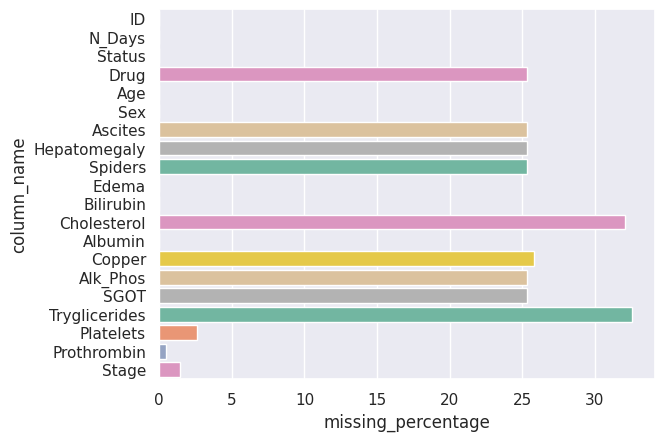

In [17]:
sns.barplot(x='missing_percentage', y='column_name', data=missing_value_df, palette=pellete);


In [ ]:

# Describe object columns
cirrhosis_df.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
ID,418.000,209.500,120.810,1.000,105.250,209.500,313.750,418.000
N_Days,418.000,1917.782,1104.673,41.000,1092.750,1730.000,2613.500,4795.000
Age,418.000,18533.352,3815.845,9598.000,15644.500,18628.000,21272.500,28650.000
Bilirubin,418.000,3.221,4.408,0.300,0.800,1.400,3.400,28.000
Cholesterol,284.000,369.511,231.945,120.000,249.500,309.500,400.000,1775.000
Albumin,418.000,3.497,0.425,1.960,3.243,3.530,3.770,4.640
Copper,310.000,97.648,85.614,4.000,41.250,73.000,123.000,588.000
Alk_Phos,312.000,1982.656,2140.389,289.000,871.500,1259.000,1980.000,13862.400
SGOT,312.000,122.556,56.700,26.350,80.600,114.700,151.900,457.250
Tryglicerides,282.000,124.702,65.149,33.000,84.250,108.000,151.000,598.000


In [ ]:

# Describe object columns
cirrhosis_df.select_dtypes(include='object').describe().T
     

,count,unique,top,freq
Status,418,3,C,232
Drug,312,2,D-penicillamine,158
Sex,418,2,F,374
Ascites,312,2,N,288
Hepatomegaly,312,2,Y,160
Spiders,312,2,N,222
Edema,418,3,N,354
